<a href="https://colab.research.google.com/github/Kamruzzaman2200/Ai/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install & Import Libraries

In [25]:
!pip install -q imbalanced-learn ucimlrepo


In [26]:
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


#Load UCI Heart Disease Dataset (OFFICIAL)

In [27]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nMetadata:\n", heart_disease.metadata)
print("\nVariables:\n", heart_disease.variables)


Features shape: (303, 13)
Target shape: (303, 1)

Metadata:
 {'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery d

#Preprocessing & Target Conversion

In [28]:
y = y.iloc[:, 0]          # extract target column
y = y.apply(lambda x: 1 if x > 0 else 0)

# Handle missing values
X = X.replace('?', np.nan)
X = X.apply(pd.to_numeric)

# Drop rows with missing values (standard for Cleveland)
mask = X.notnull().all(axis=1)
X = X[mask]
y = y[mask]

print("Final shape:", X.shape)
print("Class distribution:\n", y.value_counts())


Final shape: (297, 13)
Class distribution:
 num
0    160
1    137
Name: count, dtype: int64


#Data Quality

In [29]:
print("Missing values per feature:")
print(X.isnull().sum())

print("\nData types:")
print(X.dtypes)

print("\nBasic statistics:")
X.describe()


Missing values per feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Basic statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


#Target Variable Analysis

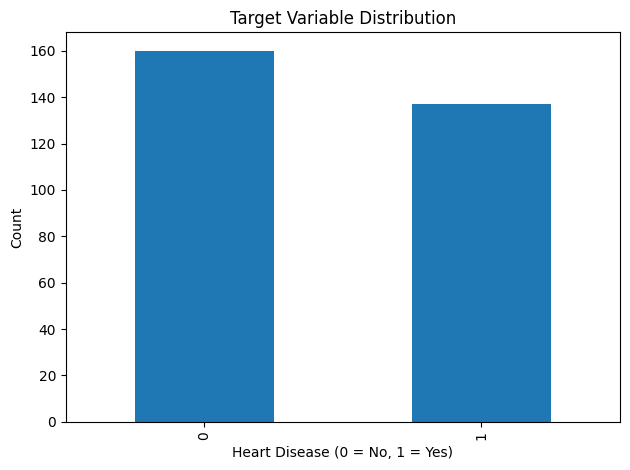

Class ratio:
num
0    0.538721
1    0.461279
Name: proportion, dtype: float64


In [30]:
import matplotlib.pyplot as plt

plt.figure()
y.value_counts().plot(kind='bar')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
plt.tight_layout()
plt.show()

print("Class ratio:")
print(y.value_counts(normalize=True))


#EDA

#EDA: Target Variable Distribution

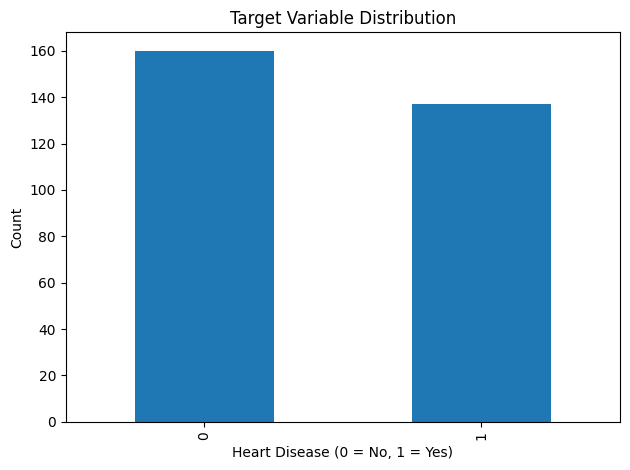

In [31]:
import matplotlib.pyplot as plt

plt.figure()
y.value_counts().plot(kind='bar')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
plt.tight_layout()
plt.show()


#EDA: Categorical Features vs Target

<Figure size 640x480 with 0 Axes>

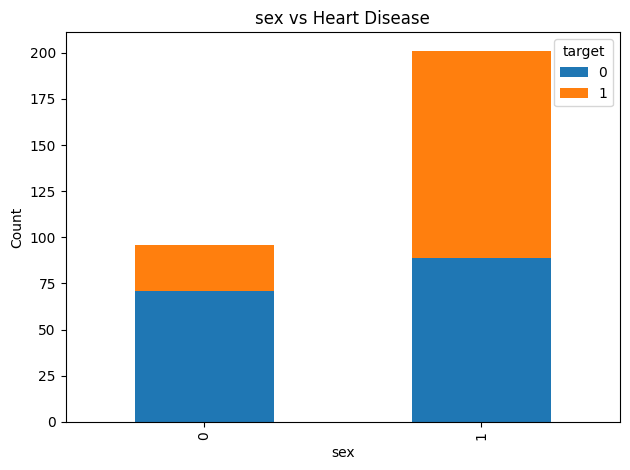

<Figure size 640x480 with 0 Axes>

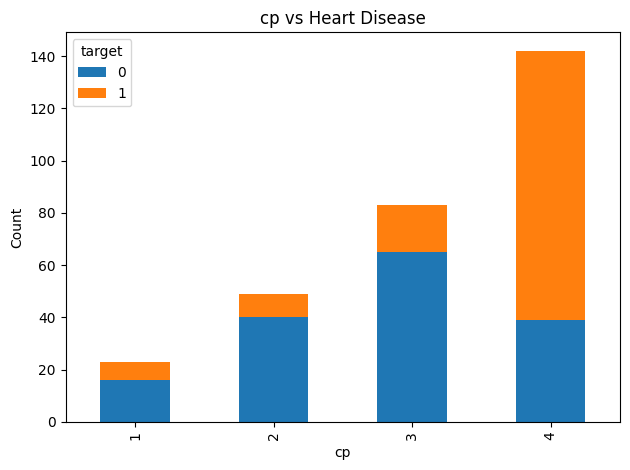

In [33]:
categorical_features = ['sex', 'cp']

data = X.copy()
data['target'] = y # y is a Series and will be added as a column

for col in categorical_features:
    plt.figure()
    pd.crosstab(data[col], data['target']).plot(kind='bar', stacked=True)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'{col} vs Heart Disease')
    plt.tight_layout()
    plt.show()

#EDA: Numerical Features Distribution

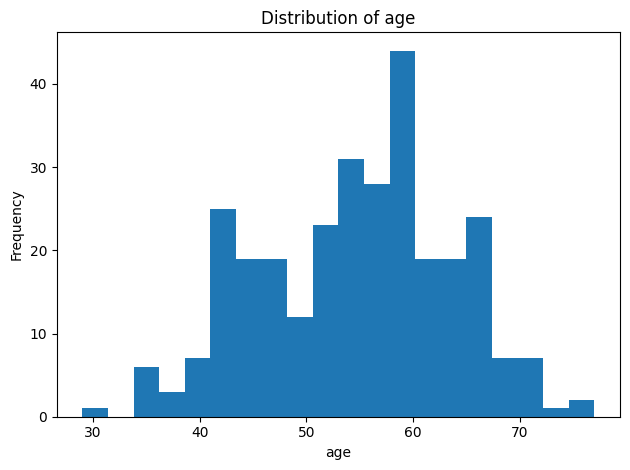

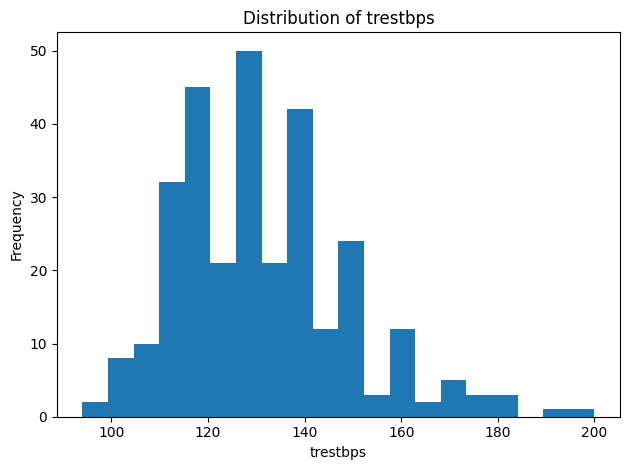

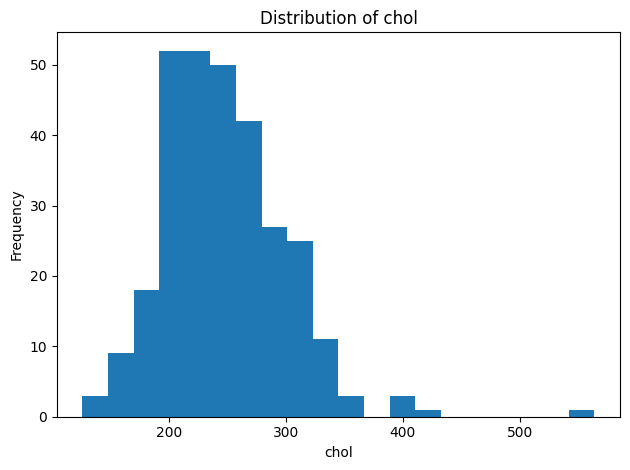

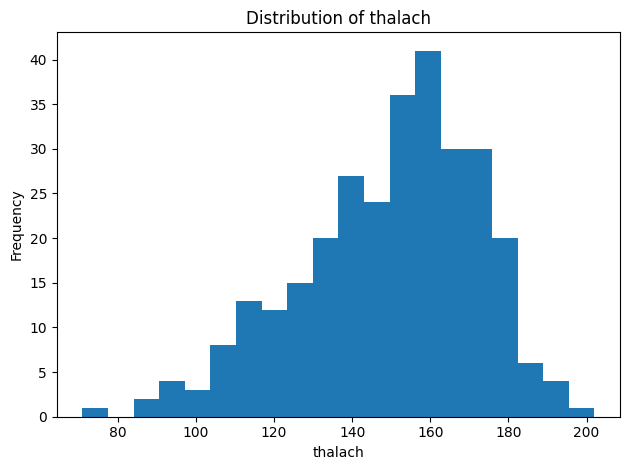

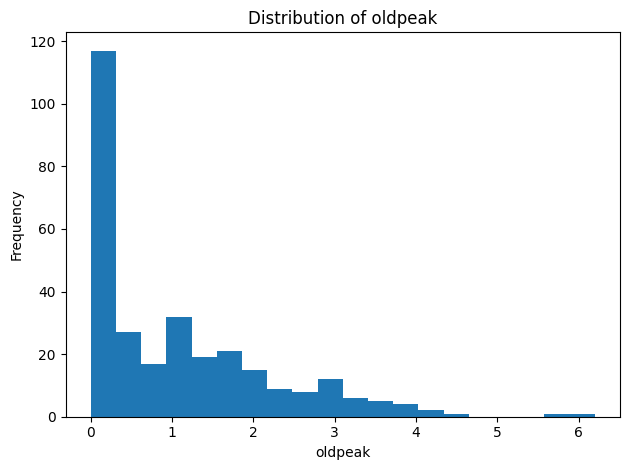

In [34]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in numerical_features:
    plt.figure()
    plt.hist(data[col], bins=20)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


#Correlation Heatmap

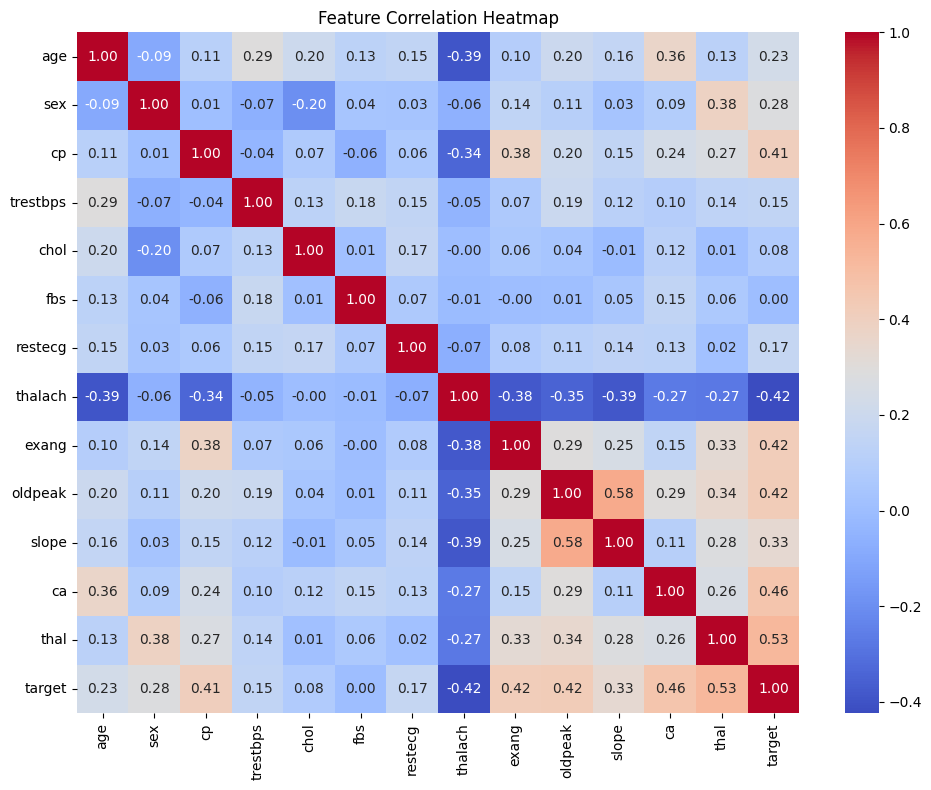

In [36]:
import seaborn as sns

corr = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

#Outlier Detection Using IQR (EDA ONLY)

In [37]:
numerical_features = X.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in numerical_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(
    outlier_summary, orient='index', columns=['Outlier Count']
)

outlier_df.sort_values(by='Outlier Count', ascending=False)


,Outlier Count
fbs,43
cp,23
ca,20
trestbps,9
chol,5
oldpeak,5
thalach,1
sex,0
age,0
exang,0


#Hold-Out Split (Deployment Simulation)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


#Custom Hybrid Pipelines (CORE CONTRIBUTION)

#Logistic **Regression**

RobustScaler + RFE

In [39]:
pipe_lr = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', RobustScaler()),
    ('fs', RFE(
        estimator=LogisticRegression(max_iter=1000),
        n_features_to_select=8
    )),
    ('clf', LogisticRegression(max_iter=1000))
])


# SVM

StandardScaler + Mutual Information

In [40]:
pipe_svm = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('fs', SelectKBest(mutual_info_classif, k=8)),
    ('clf', SVC(kernel='rbf', probability=True))
])


# KNN

MinMaxScaler + ANOVA

In [41]:
pipe_knn = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('fs', SelectKBest(f_classif, k=8)),
    ('clf', KNeighborsClassifier())
])


# Random Forest

Embedded Feature Selection

In [42]:
pipe_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])


#Hyperparameter Search Spaces

In [43]:
param_lr = {
    'fs__n_features_to_select': [6, 8, 10],
    'clf__C': [0.1, 1, 10]
}

param_svm = {
    'fs__k': [6, 8, 10],
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto']
}

param_knn = {
    'fs__k': [6, 8, 10],
    'clf__n_neighbors': [5, 7, 9]
}

param_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20]
}


#Nested Cross-Validation

In [44]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_lr  = GridSearchCV(pipe_lr,  param_lr,  cv=inner_cv, scoring='f1', n_jobs=-1)
gs_svm = GridSearchCV(pipe_svm, param_svm, cv=inner_cv, scoring='f1', n_jobs=-1)
gs_knn = GridSearchCV(pipe_knn, param_knn, cv=inner_cv, scoring='f1', n_jobs=-1)
gs_rf  = GridSearchCV(pipe_rf,  param_rf,  cv=inner_cv, scoring='f1', n_jobs=-1)

estimators = [
    ('lr', gs_lr),
    ('svm', gs_svm),
    ('knn', gs_knn),
    ('rf', gs_rf)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

cv_scores = cross_val_score(
    stack_model,
    X_train,
    y_train,
    cv=outer_cv,
    scoring='f1',
    n_jobs=-1
)

print("Nested CV F1-score:", cv_scores.mean(), "+/-", cv_scores.std())


Nested CV F1-score: 0.7771993224167137 +/- 0.07455235135568425


#Train Final Model

In [45]:
stack_model.fit(X_train, y_train)

StackingClassifier(estimators=[('lr',
                                GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                             estimator=Pipeline(steps=[('smote',
                                                                        SMOTE(random_state=42)),
                                                                       ('scaler',
                                                                        RobustScaler()),
                                                                       ('fs',
                                                                        RFE(estimator=LogisticRegression(max_iter=1000),
                                                                            n_features_to_select=8)),
                                                                       ('clf',
                                                                        LogisticRegression(max_iter=1000))]),
                                             n_jobs=-1,
                                             param_grid={'clf__C': [...
                                GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                             estimator=Pipeline(steps=[('smote',
                                                                        SMOTE(random_state=42)),
                                                                       ('clf',
                                                                        RandomForestClassifier(random_state=42))]),
                                             n_jobs=-1,
                                             param_grid={'clf__max_depth': [None,
                                                                            10,
                                                                            20],
                                                         'clf__n_estimators': [100,
                                                                               200]},
                                             scoring='f1'))],
                   final_estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
                   stack_method='predict_proba')

#Compute Accuracy & AUC via Cross-Validation

In [46]:
from sklearn.model_selection import cross_validate

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_metrics = cross_validate(
    stack_model,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=-1
)

print("CUSTOM HYBRID MODEL (Nested CV)")
print("Accuracy :", cv_metrics['test_accuracy'].mean())
print("F1-score :", cv_metrics['test_f1'].mean())
print("AUC      :", cv_metrics['test_roc_auc'].mean())


CUSTOM HYBRID MODEL (Nested CV)
Accuracy : 0.801595744680851
F1-score : 0.7771993224167137
AUC      : 0.8854305694305694


#Proper Baseline Models (FAIR COMPARISON)

#Each baseline:

Uses scaling

Uses SMOTE

Uses GridSearchCV

Uses cross-validation



#Logistic Regression (Baseline)

In [47]:
pipe_lr_base = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

param_lr_base = {
    'clf__C': [0.1, 1, 10]
}

gs_lr_base = GridSearchCV(
    pipe_lr_base,
    param_lr_base,
    cv=inner_cv,
    scoring='f1',
    n_jobs=-1
)


#SVM (Baseline)

In [48]:
pipe_svm_base = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True))
])

param_svm_base = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto']
}

gs_svm_base = GridSearchCV(
    pipe_svm_base,
    param_svm_base,
    cv=inner_cv,
    scoring='f1',
    n_jobs=-1
)


#Random Forest (Baseline)

In [49]:
pipe_rf_base = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

param_rf_base = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20]
}

gs_rf_base = GridSearchCV(
    pipe_rf_base,
    param_rf_base,
    cv=inner_cv,
    scoring='f1',
    n_jobs=-1
)


#Compare Baselines vs Custom Model

In [50]:
models = {
    'Logistic Regression': gs_lr_base,
    'SVM': gs_svm_base,
    'Random Forest': gs_rf_base,
    'Custom Hybrid Model': stack_model
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'F1-score': scores['test_f1'].mean(),
        'AUC': scores['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,F1-score,AUC
0,Logistic Regression,0.805762,0.784155,0.874392
1,SVM,0.810284,0.787323,0.871272
2,Random Forest,0.801507,0.775001,0.880631
3,Custom Hybrid Model,0.801596,0.779797,0.884972


#Bar Chart Comparing F1-Scores

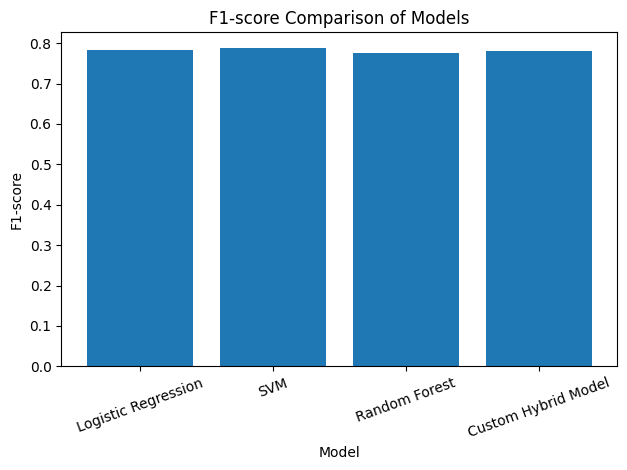

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df['Model'], results_df['F1-score'])
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.title('F1-score Comparison of Models')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


#ROC Curve for Custom Hybrid Model

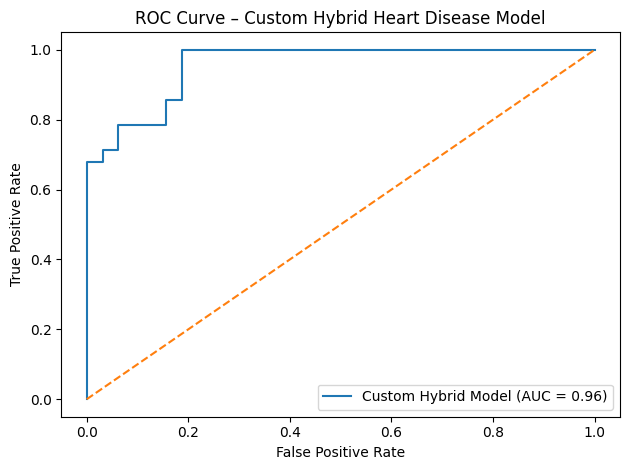

In [52]:
from sklearn.metrics import roc_curve, auc

# Get probabilities from trained custom model
y_prob_custom = stack_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_custom)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Custom Hybrid Model (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Custom Hybrid Heart Disease Model')
plt.legend()
plt.tight_layout()
plt.show()


ROC curve looks like this because my model is strong and the dataset is small

#Confusion Matrix (Custom Hybrid Model)

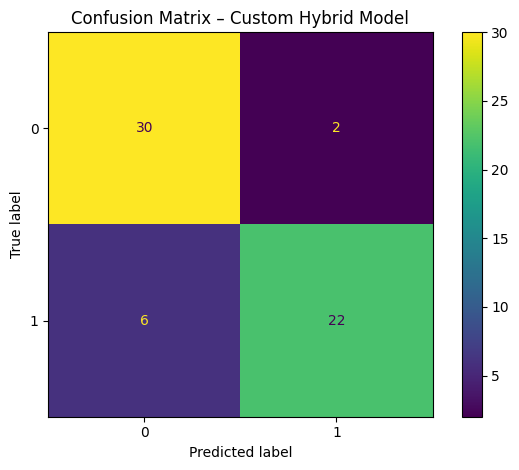

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = stack_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix – Custom Hybrid Model')
plt.tight_layout()
plt.show()

#Learning Curves

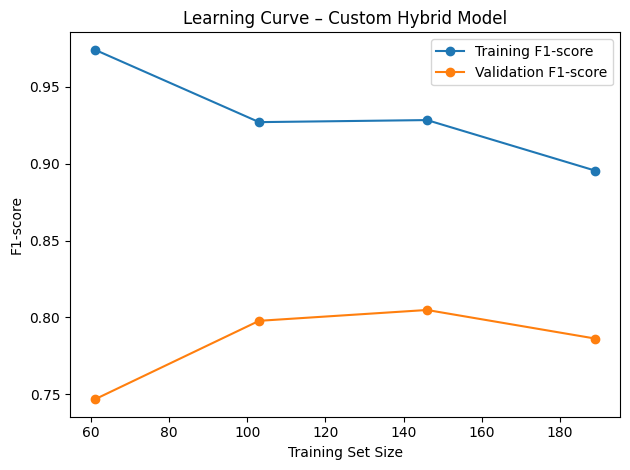

In [54]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    stack_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker='o', label='Training F1-score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation F1-score')
plt.xlabel('Training Set Size')
plt.ylabel('F1-score')
plt.title('Learning Curve – Custom Hybrid Model')
plt.legend()
plt.tight_layout()
plt.show()
